# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

In [140]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


### Cargar Dataset

In [141]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [142]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfacción`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad`es de tipo float64; es necesario convertirlo a int64.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [143]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)

In [144]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [145]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


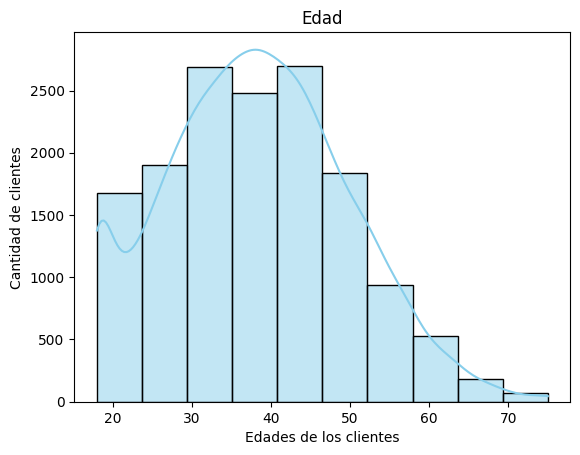

In [146]:
sns.histplot(df['edad'], bins=10, color='skyblue', kde=True)
plt.xlabel('Edades de los clientes')
plt.ylabel('Cantidad de clientes')
plt.title('Edad')
plt.show()

-La información presentada en la columna `edad` es confiable debido a que presenta un rango de edades coherente que va de los 18 a los 75 años (min y max respectivamente). Aunado a ello, podemos observar que la distribución de los datos no muestra outliers que puedan interferir más adelante en el análisis.
También cabe destacar que el Q3 está compuesto por adultos y adultos jóvenes; siendo los clientes de 46 años el límite de dicho cuartil.

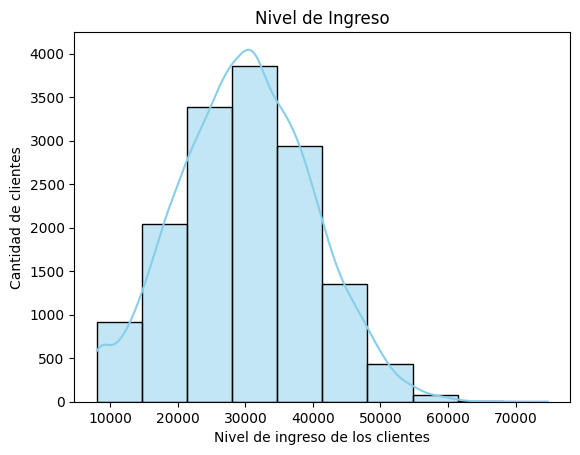

In [147]:
sns.histplot(df['nivel_ingreso'], bins=10, color='skyblue', kde=True)
plt.xlabel('Nivel de ingreso de los clientes')
plt.ylabel('Cantidad de clientes')
plt.title('Nivel de Ingreso')
plt.show()

-Dentro de la columna `nivel_ingreso`la desviación estándar nos muestra que los ingresos de los clientes, si bien presentan una variabilidad importante, ésta se encuentra controlada alrededor del promedio (`$30k`). Se debe destacar que la base de datos incluye diferentes niveles de ingresos que oscilan entre `$8k` y `$74k`

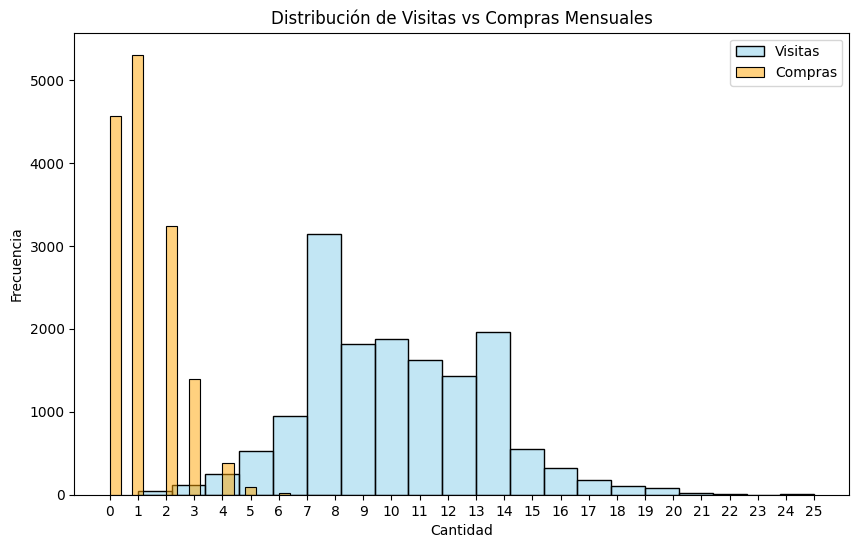

In [148]:
plt.figure(figsize=(10,6))

sns.histplot(df["visitas_mes"], bins=20, color="skyblue", label="Visitas", alpha=0.5)
sns.histplot(df["compras_mes"], bins=20, color="orange", label="Compras", alpha=0.5)

plt.title("Distribución de Visitas vs Compras Mensuales")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")

plt.xticks(range(int(df["compras_mes"].min()), int(df["visitas_mes"].max())+1, 1))

plt.legend()
plt.show()

La relación entre `visitas` y `compras` sugiere una tasa de conversión aproximada del 10% (tomando en cuenta sus respectivos promedios), lo que indica un nivel de conversión relativamente alto en comparación con promedios típicos de comercio electrónico (1 al 4%).
Valdría la pena profundizar en los datos recabados en la columna de `visitas` con el fin de identificar la razón por la cual existen valores atípicos en cuanto a la actividad de la mayoría de clientes dentro de la plataforma (max de 25 y Q3 de 18).

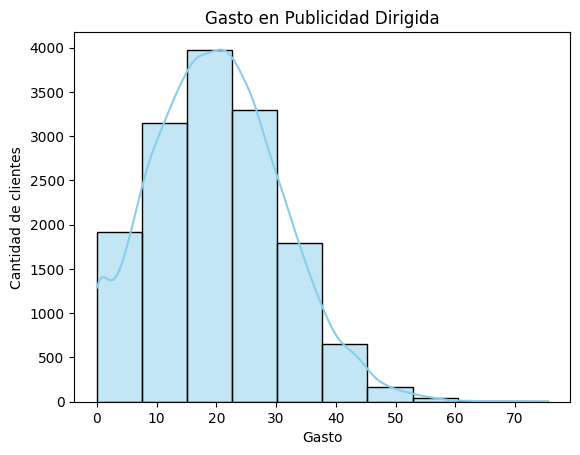

In [149]:
sns.histplot(df['gasto_publicidad_dirigida'], bins=10, color='skyblue', kde=True)
plt.xlabel('Gasto')
plt.ylabel('Cantidad de clientes')
plt.title('Gasto en Publicidad Dirigida')
plt.show()

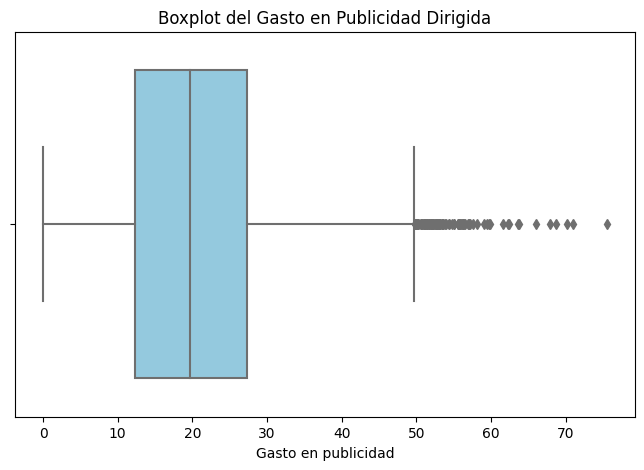

In [150]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["gasto_publicidad_dirigida"], color="skyblue")

plt.title("Boxplot del Gasto en Publicidad Dirigida")
plt.xlabel("Gasto en publicidad")

plt.show()

-Para la columna `gasto_publicidad_dirigida` la mayoría del gasto se concentra entre 12 y 27 aproximadamente; sin embargo, es evidente que contamos con outliers y una alta variabilidad de gasto. Para decidir que tratamiento es el correcto, debemos indagar si existen estrategias de segmentación en la asignación del presupuesto publicitario, ya que también existen clientes que no reciben inversión alguna.

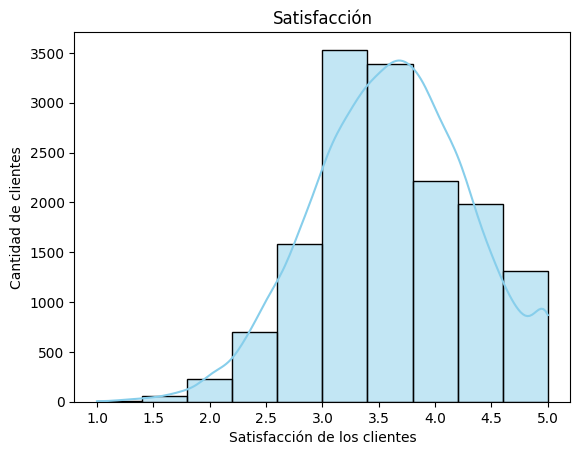

In [151]:
sns.histplot(df['satisfaccion'], bins=10, color='skyblue', kde=True)
plt.xlabel('Satisfacción de los clientes')
plt.ylabel('Cantidad de clientes')
plt.title('Satisfacción')
plt.show()

-La mayoría de los clientes (Q1-Q3) de NovaRetail+ califica su experiencia entre un 3 y 4. Un aspecto a analizar es si la `satisfacción` depende de la compra o no; es decir, si la satisfacción aumenta o disminuye por dicha variable. Una vez que podamos identificar lo anteriormente mencionado, se podrían proponer estrategias para aumentar la calificación por parte de los clientes e incluso, mejorar y modificar procesos para poder llegar a la compra.

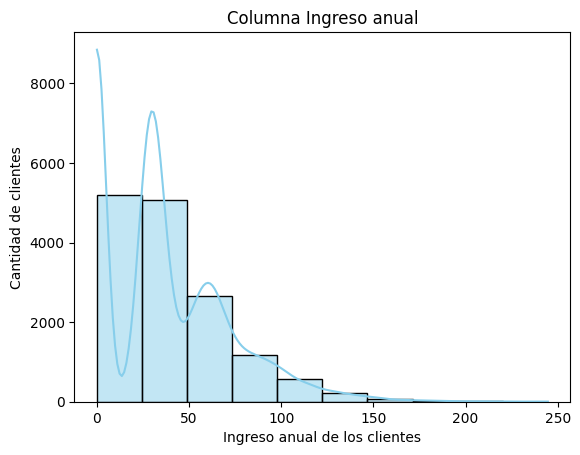

In [152]:
sns.histplot(df['ingreso_anual'], bins=10, color='skyblue', kde=True)
plt.xlabel('Ingreso anual de los clientes')
plt.ylabel('Cantidad de clientes')
plt.title('Columna Ingreso anual')
plt.show()

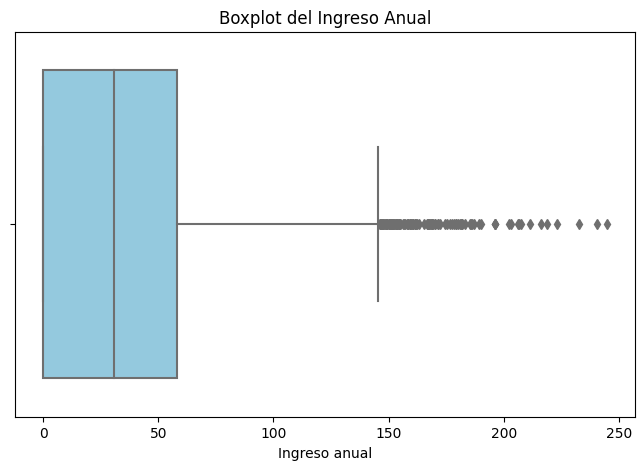

In [153]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["ingreso_anual"], color="skyblue")

plt.title("Boxplot del Ingreso Anual")
plt.xlabel("Ingreso anual")

plt.show()

Nuevamente nos encontramos con outliers en la columna de `ingreso_anual` lo que nos llevaría a fortalecer la teoría de que existe un segmento de clientes que si bien representan un gasto más fuerte en publicidad, también podrían estar generando mayores ganancias a NovaRetail+. El siguiente paso sería investigar las categorías en las que se divide a los clientes e incluso, se recomendaría analizar sus preferencias de compra. A partir de lo anterior, se podrían llevar a cabo análisis de correlación para realizar propuestas de marketing/sales robustas y bien dirigidas.
Debemos destacar que el 25% de los visitantes de la plataforma únicamente la exploran y no representan una ganancia para la empresa; a partir de este dato del Q1 se podrían impulsar estrategias que permitieran retener al cliente potencial no sólo en la navegación sino en la adquisición de productos.

#### Explorar variables binarias

In [154]:
# Verificar que cada columna tenga únicamente dos valores posibles
for col in ['miembro_premium','abandono']:
    print(col, df[col].unique())


miembro_premium [0 1]
abandono [0 1]


In [155]:
# Contar clientes premium
premium_count = (df["miembro_premium"] == 1).sum()

# Total de clientes
total_clientes = len(df)

# Calcular porcentaje
porcentaje_premium = (premium_count / total_clientes) * 100

print("Clientes premium:", premium_count)
print("Total de clientes:", total_clientes)
print(f"Proporción de clientes premium: {porcentaje_premium:.2f}%")


Clientes premium: 2089
Total de clientes: 15000
Proporción de clientes premium: 13.93%


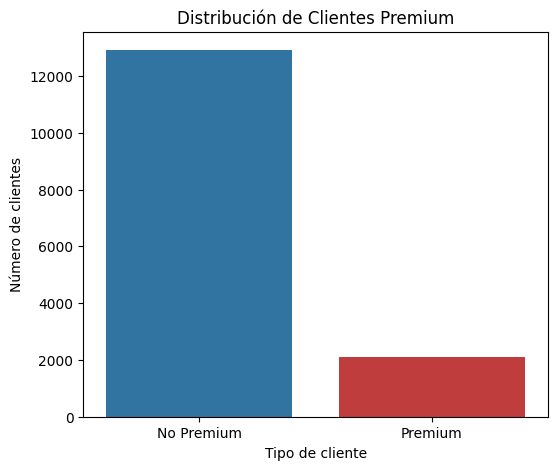

In [156]:
plt.figure(figsize=(6,5))

# Paleta personalizada: azul para "No Premium" y rojo para "Premium"
sns.countplot(
    x=df["miembro_premium"].map({0:"No Premium",1:"Premium"}), 
    palette=["#1f77b4", "#d62728"]
)

plt.title("Distribución de Clientes Premium")
plt.xlabel("Tipo de cliente")
plt.ylabel("Número de clientes")

plt.show()

-Siguiendo la hipótesis sobre la segmentación de gastos en publicidad y los outliers en la captación de ganancias, podríamos inferir que se trata de un comportamiento normal de mercado a consecuencia de los `clientes Premium`; los cuales representan el `13.93%` del total de clientes (2089). Para ahondar más en el análisis, el tipo de cliente podría sumarse a las variables a considerar en la búsqueda de correlación entre la distribución del gasto y la ganacia dentro de NovaRetail+.

In [157]:
# Contar clientes que abandonaron
abandono_count = (df["abandono"] == 1).sum()

# Total de clientes
total_clientes = len(df)

# Calcular porcentaje
porcentaje_abandono = (abandono_count / total_clientes) * 100

print("Clientes que abandonaron:", abandono_count)
print("Total de clientes:", total_clientes)
print(f"Proporción de clientes que abandonaron: {porcentaje_abandono:.2f}%")

Clientes que abandonaron: 2261
Total de clientes: 15000
Proporción de clientes que abandonaron: 15.07%


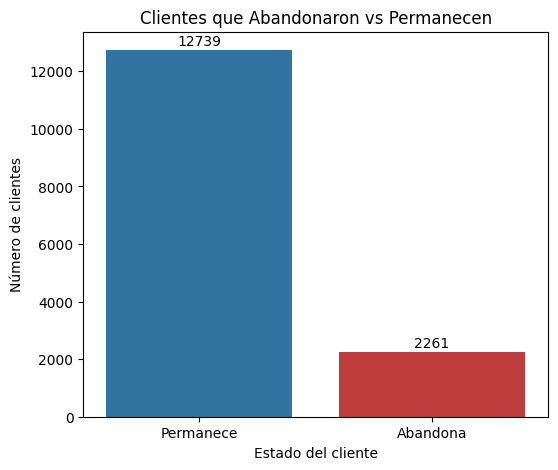

In [158]:
# Contar clientes que abandonaron y que permanecen
abandono_counts = df["abandono"].value_counts().sort_index()
labels = ["Permanece", "Abandona"]

plt.figure(figsize=(6,5))

sns.barplot(
    x=labels,
    y=abandono_counts.values,
    palette=["#1f77b4", "#d62728"]
)

# Agregar títulos y etiquetas
plt.title("Clientes que Abandonaron vs Permanecen")
plt.ylabel("Número de clientes")
plt.xlabel("Estado del cliente")

# Agregar números encima de cada barra
for i, value in enumerate(abandono_counts.values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom')

plt.show()

NovaRetail+ presenta un `churn` del `15.07%` (2261) que, comparado a los parámetros del sector e-commerce (10-20%), se considera una tasa relativamente saludable. Estudiar dicho parámetro ayudaría a identificar que factores podrían estar influyendo en la pérdida de clientes así como la planeación y ejecución de estrategias de retención.

#### Explorar variables categóricas

In [159]:
# Conteos por región y tipo de dispositivo
conteos = pd.crosstab(df["region"], df["tipo_dispositivo"])

# Porcentajes por región
porcentajes = pd.crosstab(df["region"], df["tipo_dispositivo"], normalize="index") * 100

# Combinar conteo y porcentaje
tabla = conteos.astype(str) + " (" + porcentajes.round(1).astype(str) + "%)"

# Agregar columna total
tabla["Total"] = conteos.sum(axis=1).astype(str) + " (" + (porcentajes.sum(axis=1)).round(1).astype(str) + "%)"

tabla


tipo_dispositivo,escritorio,móvil,tablet,Total
region,,,,
este,766 (25.0%),2003 (65.3%),300 (9.8%),3069 (100.0%)
norte,1125 (25.6%),2843 (64.7%),427 (9.7%),4395 (100.0%)
oeste,935 (24.5%),2489 (65.3%),386 (10.1%),3810 (100.0%)
sur,894 (24.0%),2483 (66.6%),349 (9.4%),3726 (100.0%)


In [160]:
# Contar clientes por región
region_count = df["region"].value_counts()  # cantidad de clientes por cada región

# Total de clientes
total_clientes = len(df)

# Calcular porcentaje por región
porcentaje_region = (region_count / total_clientes) * 100

# Mostrar resultados
for region in region_count.index:
    print(f"{region}: {region_count[region]} clientes ({porcentaje_region[region]:.2f}%)")

print("Total de clientes:", total_clientes)

norte: 4395 clientes (29.30%)
oeste: 3810 clientes (25.40%)
sur: 3726 clientes (24.84%)
este: 3069 clientes (20.46%)
Total de clientes: 15000


In [161]:
# Contar clientes por tipo de dispositivo
dispositivo_count = df["tipo_dispositivo"].value_counts()  # cantidad de clientes por dispositivo

# Total de clientes
total_clientes = len(df)

# Calcular porcentaje por dispositivo
porcentaje_dispositivo = (dispositivo_count / total_clientes) * 100

# Mostrar resultados
for dispositivo in dispositivo_count.index:
    print(f"{dispositivo}: {dispositivo_count[dispositivo]} clientes ({porcentaje_dispositivo[dispositivo]:.2f}%)")

print("Total de clientes:", total_clientes)


móvil: 9818 clientes (65.45%)
escritorio: 3720 clientes (24.80%)
tablet: 1462 clientes (9.75%)
Total de clientes: 15000


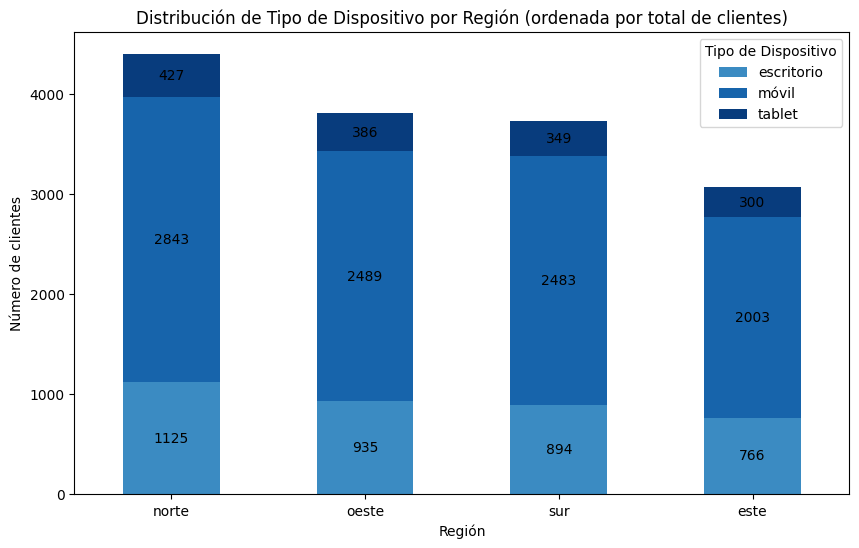

In [162]:
# Crear conteos por región y dispositivo
conteos = pd.crosstab(df["region"], df["tipo_dispositivo"])

# Ordenar las regiones de mayor a menor según el total de clientes
conteos = conteos.loc[conteos.sum(axis=1).sort_values(ascending=False).index]

num_dispositivos = len(conteos.columns)
colores = plt.cm.Blues(np.linspace(0.65, 0.95, num_dispositivos)) 

# Crear gráfico de barras apiladas
ax = conteos.plot(kind="bar", stacked=True, figsize=(10,6), color=colores)

# Agregar números dentro de cada sección
for i, region in enumerate(conteos.index):
    bottom = 0
    for j, dispositivo in enumerate(conteos.columns):
        valor = conteos.loc[region, dispositivo]
        ax.text(
            i,
            bottom + valor/2,
            str(valor),
            ha='center', va='center',
            color='black',
            fontsize=10
        )
        bottom += valor  #para el siguiente nivel

plt.title("Distribución de Tipo de Dispositivo por Región (ordenada por total de clientes)")
plt.xlabel("Región")
plt.ylabel("Número de clientes")
plt.legend(title="Tipo de Dispositivo")
plt.xticks(rotation=0)
plt.show()

Al momento de analizar el mercado por `tipo de dispositivo` y `región` podemos observar que, la región con mayor presencia, es el norte con un 29.30% (4395); sin embargo, la distribución es bastante consistente en las otras regiones (oeste 25.40%, sur 24.84% y este 20.46%). En cuanto al tipo de dispositivo más usado se puede observar que los clientes tienen una mayor preferencia por el móvil. A diferencia de la región, aquí si se muestra un sesgo importante entre preferencias (escritorio 24.80% y tablet 9.75%) pero nuevamente observamos un comportamiento uniforme entre regiones por tipo de dispositivo.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

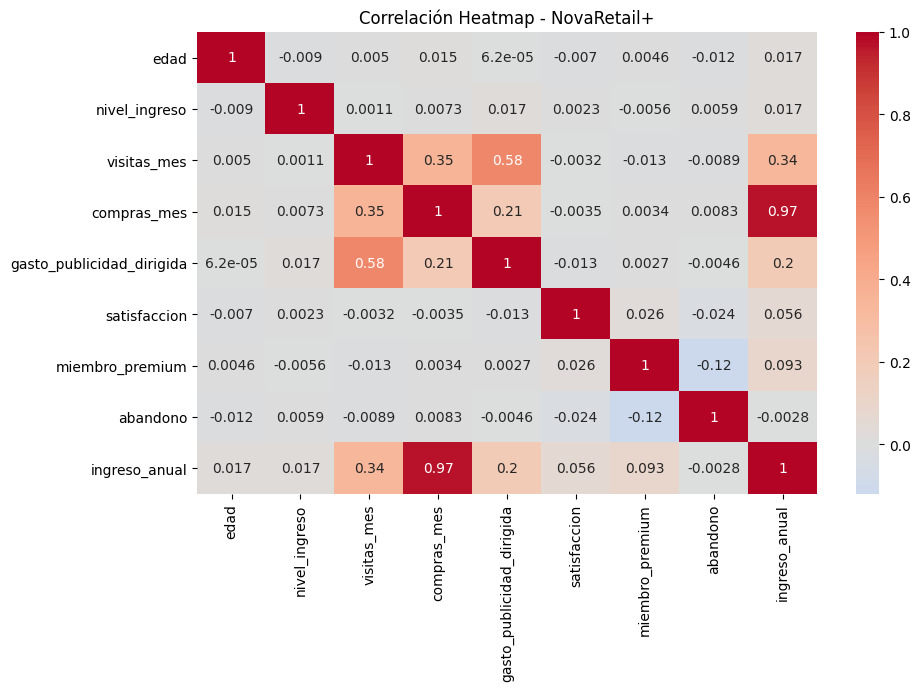

In [163]:
# Visualizar la matriz de correlación para identificar relaciones
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación Heatmap - NovaRetail+")

plt.show()

✍️ **Observaciones generales**

Se encontraron las siguientes correlaciones:

-Visitas mes - gasto publicidad dirigida (0.58)

-Visitas mes - compras mes (0.35)

-Compras mes - gasto publicidad dirigida (0.21)

-Miembro premium - abandono (-0.12)

Como podemos observar, las variables de `visitas_mes`, `compras_mes` y `gasto publicidad_dirigida`cuentan con una correlación entre ellas. Dicha correlación puede apoyarnos en la planeación y ejecución de estrategias de marketing y ventas que nos permitan no sólo retener sino hacer crecer la captación de clientes e incluso, entender el comportamiento y necesidades específicas del mercado en general. 

La correlación con mayor importancia es la de `visitas mes`y `gasto publicidad`, entendiendo este hallazgo como: la inversión que inyecta en publicidad NovaRetail+ se está traduciendo en visitas más no en compra de productos: sin embargo, no dejemos de lado que la tasa de conversión expuesta en el inciso anterior, es óptima y positiva para el mercado de interés (e-commerce).

Un punto relevante a destacar es que la correlación negativa (aunque débil) entre `clientes premium` y `abandono` sugiere que, en combinación con otros factores como la `satisfacción` del cliente, la estrategia de fidelización podría contribuir a reducir la probabilidad de abandono en la plataforma de NovaRetail+. Este insight es de suma importancia para el área de mercadotecnia porque como los datos mostraron anteriormente, el 86.07% de los clientes no cuentan con suscripción a dicha categoría y podrían representar una  oportunidad de crecimiento y ventas de gran peso para la compañía. 

✍️ **Observaciones respecto al ingreso anual**

Las variables que tienen correlación con el ingreso anual, son las siguientes:

-Compras mes (0.97)

-Visitas mes (0.34)

-Gasto publicidad dirigida (0.2)


La variable `compras mes` presenta una correlación muy alta con el ingreso anual, lo que podría indicar colinealidad, ya que ambas variables se mueven de manera muy similar y aportan información redundante.

Por otro lado, `visitas mes` y `gasto publicidad dirigida` muestran una relación positiva, pero débil. Sería recomendable analizar a qué segmentos de mercado o productos se están dirigiendo estas campañas, con el fin de optimizar los recursos y maximizar las ganancias derivadas de la inversión en publicidad.


### Scatterplot general

Con base en los resultados del análisis de correlación, no es necesario generar un *scatterplot* general. Las correlaciones que deben ser sometidas a ánalisis son puntuales y específicas; por ello, se decide presentar Scatterplot individual para explicar sus hallazgos y comportamientos.

### Scatterplot para pares clave

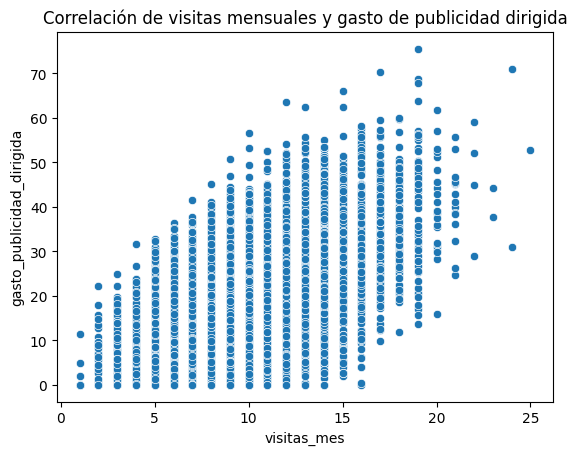

In [164]:
# Visualizar pares de variables con relaciones moderadas o fuertes

sns.scatterplot(data=df,x="visitas_mes", y="gasto_publicidad_dirigida")
plt.title("Correlación de visitas mensuales y gasto de publicidad dirigida")
plt.show()


Se observa una *tendencia positiva* ya que, a medida que aumentan las visitas mensuales, el gasto de publicidad dirigida tiende a aumentar también; sin embargo, los *puntos* están bastante *dispersos* mostrando que para un mismo número de visitas existen muchos niveles distintos de gasto en publicidad.

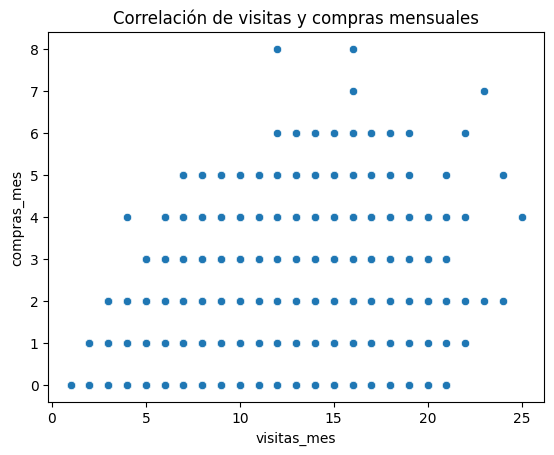

In [165]:
sns.scatterplot(data=df,x="visitas_mes", y="compras_mes")
plt.title("Correlación de visitas y compras mensuales")
plt.show()

Existe una *tendencia positiva* entre variables ya que, a medida que aumentan las visitas mensuales, también tiende a aumentar el número de compras. Con una correlación de 0.35 podemos observar que los puntos se encuentran muy dispersos sugiriendo que si bien se podría sugerir que a mayor cantidad de visitas mayor cantidad de compras, existen *variables ocultas* que pueden estar influyendo en dicho resultado.  

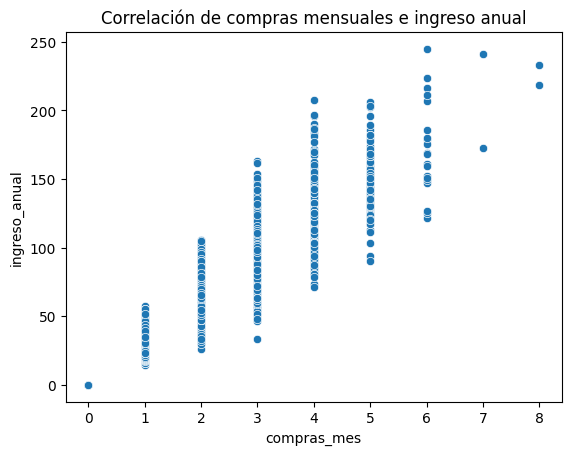

In [166]:

sns.scatterplot(data=df,x="compras_mes", y="ingreso_anual")
plt.title("Correlación de compras mensuales e ingreso anual")
plt.show()


El gráfico muestra una *tendencia positiva*; sin embargo, las variables están estrechamente vinculadas, lo que podría indicar la presencia de colinealidad. El ingreso anual se calcula a partir de las compras mensuales realizadas por los clientes, esto afectaría el análisis solicitado ya que se obtendría información redundante.

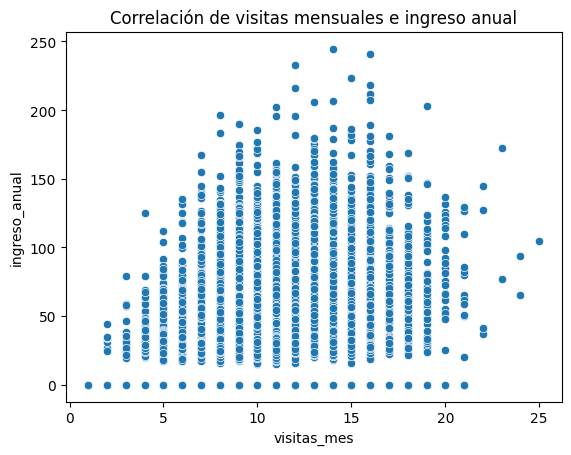

In [167]:
sns.scatterplot(data=df,x="visitas_mes", y="ingreso_anual")
plt.title("Correlación de visitas mensuales e ingreso anual")
plt.show()

Se muestra una relación *positiva moderada*. Esto sugiere que las visitas sí influyen en el ingreso, pero de manera limitada, por lo que otros factores también juegan un papel importante.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [168]:
# Calcular correlación entre variables relevantes
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

columnas = ["visitas_mes", "compras_mes", "gasto_publicidad_dirigida", "ingreso_anual"]

def numeric_corr(df, columnas):
    pearson_corr = df[columnas].corr(method='pearson')
    spearman_corr = df[columnas].corr(method='spearman')

    print("Correlación Pearson:")
    print(pearson_corr)

    print("\nCorrelación Spearman:")
    print(spearman_corr)

# Ejecutar función
numeric_corr(df, columnas)

Correlación Pearson:
                           visitas_mes  compras_mes  \
visitas_mes                   1.000000     0.353844   
compras_mes                   0.353844     1.000000   
gasto_publicidad_dirigida     0.578947     0.207528   
ingreso_anual                 0.337147     0.967149   

                           gasto_publicidad_dirigida  ingreso_anual  
visitas_mes                                 0.578947       0.337147  
compras_mes                                 0.207528       0.967149  
gasto_publicidad_dirigida                   1.000000       0.197483  
ingreso_anual                               0.197483       1.000000  

Correlación Spearman:
                           visitas_mes  compras_mes  \
visitas_mes                   1.000000     0.332943   
compras_mes                   0.332943     1.000000   
gasto_publicidad_dirigida     0.559267     0.192511   
ingreso_anual                 0.320954     0.967482   

                           gasto_publicidad_dirigida  

**Se usará el método de `Pearson` debido a que las correlaciones con Spearman son casi iguales y las relaciones parecen lineales.**

##### ✍️Insights:

**gasto_publicidad_dirigida ↔ visitas_mes = 0.58**

**gasto_publicidad_dirigida ↔ ingreso_anual = 0.20**

Existe una correlación positiva moderada-alta entre el gasto en publicidad dirigida y las visitas a la plataforma. En términos de negocio se puede visualizar que la inversión en publicidad está generando navegación dentro de la plataforma de NovaRetail+; sin embargo, no se está convirtiendo en ganancias debido a la baja relación que tiene con el ingreso anual. Para mejorar el ROI se recomienda analizar la segmentación de campañas publicitarias (por mercado objetivo y productos ofertados).


**visitas_mes ↔ compras_mes = 0.35**

Existe una correlación positiva moderada entre las visitas y las compras mensuales. Si bien los clientes que visitan más la plataforma tienden a comprar más, no todas las visitas se convierten en compra. Como lo mencioné en el inciso anterior, se debe buscar aumentar la conversión; esto mediante el cuidado de otras variables tales como: satisfacción del cliente (en todas y cada una de las etapas del funnel), campañas de publicidad orientadas a mercado y productos objetivo e incluso, se podría llegar a sugerir la fidelización de clientes.


**compras_mes ↔ ingreso_anual = 0.97**

Existe una correlación extremadamente fuerte entre el número de compras mensuales y el ingreso anual generado por los clientes; es decir, el ingreso depende directamente del número de compras. Dicha correlación indica *colinealidad* y afecta el análisis al brindar información reduntante.

### Punto-biserial

In [177]:
import pandas as pd
from scipy.stats import pointbiserialr

# Cargar dataset
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

# Columnas numéricas a analizar
columnas_numericas = [
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

# Función para calcular correlación point-biserial
def corr_point_biserial(df, col_binaria, columnas_numericas):

    for col in columnas_numericas:
        coef, p_value = pointbiserialr(df[col_binaria], df[col])

        print(f"\nCorrelación entre {col_binaria} y {col}")
        print(f"Coeficiente Point-Biserial: {coef:.4f}")
        print(f"p-value: {p_value:.4f}")

# Ejecutar función
corr_point_biserial(df, "miembro_premium", columnas_numericas)


Correlación entre miembro_premium y visitas_mes
Coeficiente Point-Biserial: -0.0127
p-value: 0.1211

Correlación entre miembro_premium y compras_mes
Coeficiente Point-Biserial: 0.0034
p-value: 0.6744

Correlación entre miembro_premium y gasto_publicidad_dirigida
Coeficiente Point-Biserial: 0.0027
p-value: 0.7390

Correlación entre miembro_premium y satisfaccion
Coeficiente Point-Biserial: 0.0257
p-value: 0.0016

Correlación entre miembro_premium y ingreso_anual
Coeficiente Point-Biserial: 0.0931
p-value: 0.0000


##### ✍️Insight:    
A pesar de que el programa premium podría estar aportando valor en satisfacción y generación de ingresos, su impacto en el comportamiento de compra y uso de inversión, es limitado. Nuevamente se recomienda fortalecer las estrategias de fidelización y uso de recursos de publicidad.

### V de Cramér

In [180]:
from scipy.stats import chi2_contingency
from itertools import combinations

# Cargar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

# Variables categóricas
columnas_categoricas = [
    "miembro_premium",
    "tipo_dispositivo",
    "abandono",
    "region"
]

# Función para calcular V de Cramér
def cramers_v(df, col1, col2):
    
    tabla = pd.crosstab(df[col1], df[col2])
    
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    
    n = tabla.sum().sum()
    
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    
    return v, p_value


# Calcular para todas las combinaciones de variables
for col1, col2 in combinations(columnas_categoricas, 2):
    
    v, p = cramers_v(df, col1, col2)
    
    print(f"\nCorrelación entre {col1} y {col2}")
    print(f"V de Cramér: {v:.4f}")
    print(f"p-value: {p:.4f}")


Correlación entre miembro_premium y tipo_dispositivo
V de Cramér: 0.0197
p-value: 0.0540

Correlación entre miembro_premium y abandono
V de Cramér: 0.1202
p-value: 0.0000

Correlación entre miembro_premium y region
V de Cramér: 0.0126
p-value: 0.4989

Correlación entre tipo_dispositivo y abandono
V de Cramér: 0.0072
p-value: 0.6746

Correlación entre tipo_dispositivo y region
V de Cramér: 0.0124
p-value: 0.5965

Correlación entre abandono y region
V de Cramér: 0.0154
p-value: 0.3117


##### ✍️ **Insight**: 

De todas las relaciones analizadas, solo una muestra asociación significativa: 

**miembro_premium ↔ abandono (0.1202)**

Como se mencionó anteriormente, el programa premium puede estar ayudando a reducir el abandono y podría ser una herramienta de fidelización de clientes en la plataforma de NovaRetail+.

## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — Impacto de la publicidad en el tráfico y compras dentro de la plataforma

**Evidencia visual:**  

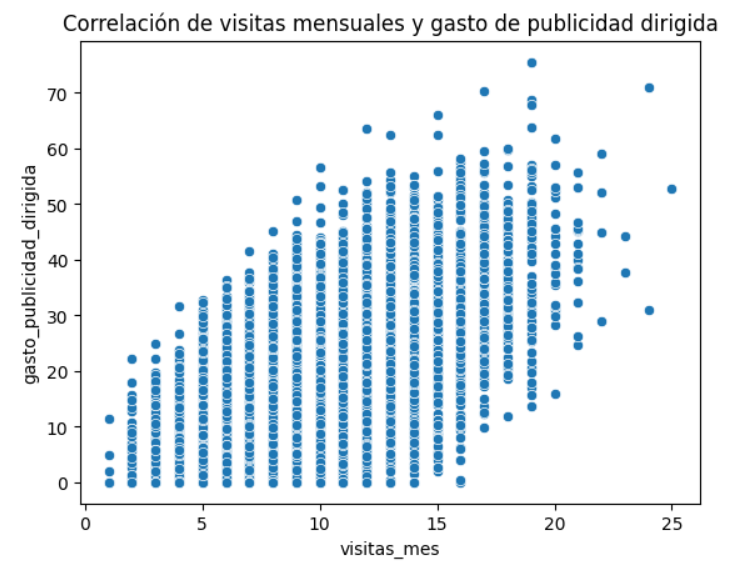

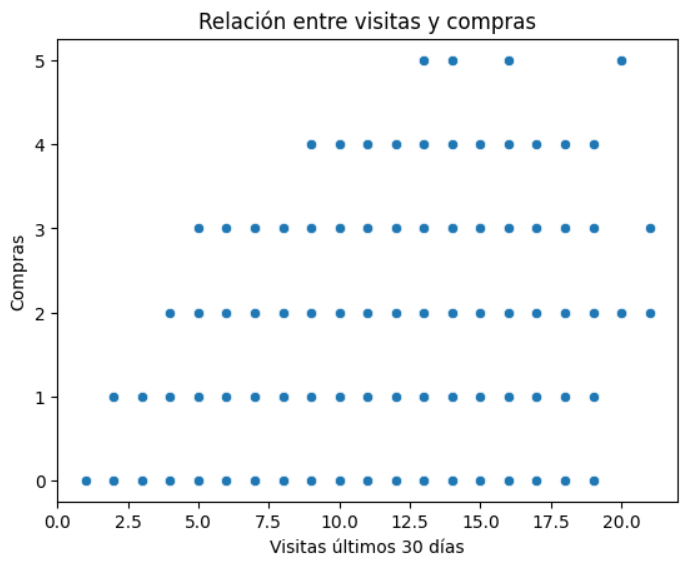


**Evidencia numérica:** 



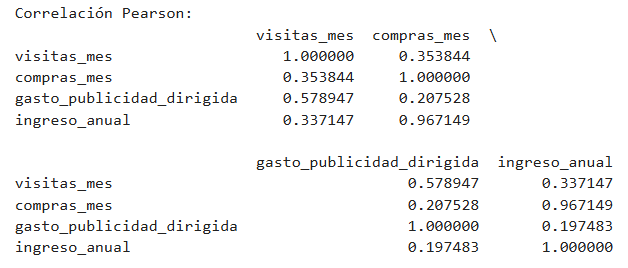



**Interpretación**  

Se observa una correlación positiva moderada-alta (0.58) entre el gasto en publicidad dirigida y las visitas mensuales a la plataforma. Este resultado sugiere que la inversión en campañas publicitarias está siendo efectiva para atraer usuarios y generar navegación dentro de la plataforma de NovaRetail+.

Sin embargo, la relación entre gasto en publicidad dirigida e ingreso anual es débil (0.20), lo que indica que el aumento en visitas no se está traduciendo proporcionalmente en mayores ingresos. Esto podría sugerir que el tráfico generado por las campañas no se está convirtiendo en compras de manera eficiente.

Aunado a ello, el análisis muestra una correlación positiva moderada (0.35) entre visitas mensuales y compras mensuales. Esto indica que los usuarios que visitan con mayor frecuencia la plataforma tienden a realizar más compras, aunque la relación no es lo suficientemente fuerte como para afirmar que todas las visitas se convierten en transacciones.

**Implicación de negocio**  

Sería recomendable revisar la segmentación de las campañas publicitarias, analizando con mayor detalle el mercado objetivo y los productos promocionados, con el fin de mejorar la conversión y maximizar el retorno de la inversión (ROI)

Adicionalmete, para incrementar el número de compras a partir del tráfico existente, sería conveniente optimizar distintos aspectos del proceso de interacción del cliente, tales como:

-Mejorar la satisfacción del cliente en cada etapa del embudo de conversión.

-Optimizar la orientación de las campañas publicitarias, alineándolas con mercados y productos específicos.

-Fortalecer estrategias de fidelización, que incentiven a los usuarios a completar el proceso de compra.




### Hallazgo 2 — Impacto del programa premium en el comportamiento del cliente
  
**Evidencia numérica:** 


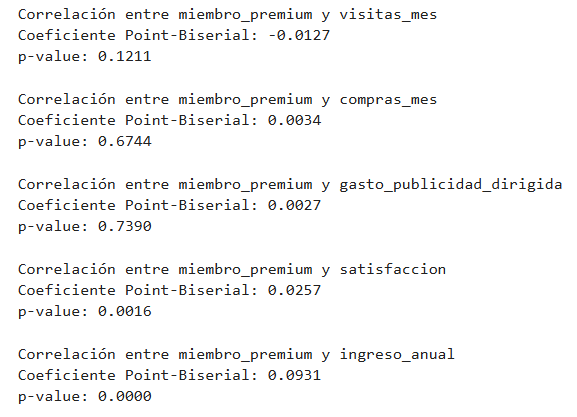




**Interpretación**  

El análisis sugiere que, aunque el programa premium parece aportar cierto valor en términos de satisfacción del cliente, su impacto sobre variables clave del comportamiento del usuario, como la frecuencia de compra y la interacción con la plataforma, es limitado.

Este resultado indica que, si bien la membresía premium podría estar contribuyendo a mejorar la percepción del servicio, no está generando cambios significativos en el patrón de consumo de los clientes.

**Implicación de negocio** 

Sería recomendable reforzar las estrategias de fidelización, así como optimizar la inversión en campañas publicitarias, con el objetivo de incentivar una mayor participación de los usuarios y mejorar la conversión dentro de la plataforma.




### Hallazgo 3 — Relación entre membresía premium y abandono
  
**Evidencia numérica:** 


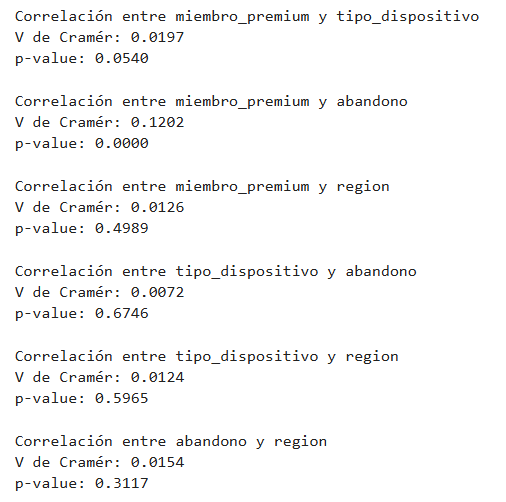




**Interpretación**  

El análisis muestra una asociación positiva pero débil (V de Cramér = 0.1202) entre miembro premium y abandono. Este resultado sugiere que el estado de membresía podría estar relacionado con diferencias en el comportamiento de permanencia de los clientes dentro de la plataforma.

**Implicación de negocio** 

En línea con los hallazgos previos, esto podría indicar que el programa premium está contribuyendo a reducir el abandono, funcionando potencialmente como una herramienta de fidelización dentro de NovaRetail+. Por lo tanto, fortalecer y optimizar los beneficios asociados a esta membresía podría ser una estrategia relevante para mejorar la retención de clientes en la plataforma.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

**1. El análisis se basa en correlaciones**

Estas métricas permiten identificar relaciones o asociaciones entre variables, pero no permiten establecer causalidad.


**2. Falta de variables explicativas adicionales**

El dataset analizado contiene variables relevantes como visitas, compras, satisfacción y publicidad; sin embargo, pueden faltar factores importantes que influyen en el comportamiento del cliente, por ejemplo: tipo de producto comprado, precios o descuentos, tiempo de permanencia en la plataforma, experiencia de usuario, historial de compras más detallado, etc.
*La ausencia de estas variables limita la capacidad de explicar completamente los patrones observados*.


**3. Relaciones estadísticamente significativas pero débiles**

Algunas relaciones encontradas son estadísticamente significativas pero con coeficientes bajos, lo que indica que el efecto real sobre el comportamiento del cliente es pequeño.


**4. Posible colinealidad entre variables de negocio**

Se identificó una correlación extremadamente alta entre compras mensuales e ingreso anual (0.97), lo que sugiere colinealidad.


**5. No se evaluó directamente la tasa de conversión del embudo**

Aunque se analizaron visitas, compras y publicidad, no se realizó un análisis completo del funnel de conversión. Esto limita la capacidad de identificar en qué etapa del proceso se están perdiendo los clientes.

### **Próximos pasos** 

A partir de los hallazgos obtenidos y considerando las limitaciones del análisis, se proponen las siguientes acciones:

**1. Optimizar la estrategia de publicidad para mejorar la conversión**

Si bien el gasto en publicidad dirigida muestra una relación moderada con el aumento de visitas a la plataforma, su impacto sobre el ingreso anual es limitado. Esto sugiere que el tráfico generado no se está convirtiendo en compras de manera eficiente.
Como siguiente paso, se recomienda analizar con mayor detalle la segmentación de las campañas, evaluando el mercado objetivo, los productos promocionados y el perfil de los clientes alcanzados. Esto permitiría ajustar las estrategias publicitarias para incrementar la tasa de conversión y mejorar el retorno de la inversión (ROI).

**2. Analizar el embudo de conversión de la plataforma**

Dado que existe una relación moderada entre visitas y compras, pero no todas las visitas se convierten en transacciones, sería útil realizar un análisis del funnel de conversión. Esto permitiría identificar en qué etapa del proceso los usuarios abandonan la compra (por ejemplo: exploración de productos, carrito, proceso de pago), facilitando la implementación de mejoras orientadas a reducir fricciones en la experiencia del usuario.

**3. Fortalecer las estrategias de fidelización y el programa premium**

El análisis sugiere que el programa premium podría estar asociado con menores niveles de abandono y mayores niveles de satisfacción, aunque su impacto sobre el comportamiento de compra es limitado. Como siguiente paso, se recomienda evaluar y fortalecer los beneficios de la membresía premium, con el objetivo de aumentar su valor percibido y fomentar una mayor participación de los clientes dentro de la plataforma.

**4. Incorporar variables adicionales para enriquecer el análisis**

Para comprender de manera más completa los factores que influyen en el comportamiento del cliente, sería conveniente incorporar nuevas variables de análisis, tales como: tipo de productos adquiridos, promociones o descuentos aplicados, tiempo de navegación en la plataforma o historial de compras más detallado. Esto permitiría construir análisis más robustos y detectar patrones de consumo más específicos.